I# Kinase prediction (kinase_library)

Annotate each phosphosite with the **top-5 kinases** most likely to phosphorylate it and
their **percentile scores** (0-100 — the site's score ranked against a reference
phosphoproteome; higher = more likely), using the `kinase_library` package
(Johnson et al. 2023 position-weight matrices).

**Design** (see `src/kinase_prediction.py`):
- Windows are cut from the **full UniProt protein sequence** using each site's absolute
  residue position, giving a true ±7 (15-mer) context. The same code path serves TMT and
  LFQ datasets (switch `DATASET_TYPE`). Each window is validated against UniProt and a
  `uniprot_seq_match` flag reports peptides that disagree (isoform / mapping issues).
- Only **single-localized** sites are scored (TMT `LocalizedNumPhos == 1`; LFQ
  `n_localized == 1 & other_localized == 0`), since the PWMs score one central residue.
- S/T sites are scored with the `ser_thr` kinome and Y sites with the `tyrosine` kinome;
  the package routes each window by its central residue automatically.

The 10 new columns (`predicted_kinase_1..5`, `predicted_kinase_1_prob..5_prob`) are flat
per-site annotations (like `functional_score` / `ERK_motif`), **not** condition data
columns, so `ColumnSpec.select()` will not sweep them up.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kinase_library as kl
from src.kinase_prediction import (
    load_uniprot_sequences,
    default_columns,
    add_kinase_windows,
    predict_top_kinases,
)
from src.cluster_composition import (
    kinase_cluster_table,
    protein_cluster_table,
    plot_cluster_composition,
)

In [3]:
# hme1_2 (TMT) is the default. Uncomment another line to annotate a different dataset.
hme1_2 = pd.read_csv("../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered.tsv", sep="\t", low_memory=False,)
# hme1_mutants = pd.read_csv("../../data/hTERT_HME1_mutants_test_sample_transformed.tsv", sep="\t", low_memory=False,)  # LFQ
hme1_2.shape

(8723, 468)

## Parameters

Everything configurable lives here. Set `DATASET_TYPE` to match the dataset in `df_raw`
(`"TMT"` for hme1_1/hme1_2/hek_1, `"LFQ"` for the mutant datasets); `default_columns()`
then resolves the dataset-specific column names (and LFQ casing) automatically.

In [4]:
# ════════════════════════════════════════════════════════════
# PARAMETERS — edit this cell to configure the kinase prediction
# ════════════════════════════════════════════════════════════

df_raw = hme1_2                      # dataset to annotate

DATASET_TYPE = "TMT"                 # "TMT" (hme1_1/hme1_2/hek_1) | "LFQ" (mutants)
TOP_N        = 5                     # number of ranked kinases to keep per site

UNIPROT_PATH = "../../External_Data/Metadata/uniprotkb_AND_reviewed_true_AND_model_o_2026_05_13_de_compressed.tsv"

# Output: input filename + _kinasepred suffix (never overwrite the source file).
OUTPUT_PATH  = "../../notebooks/03_clustering/Data_clustered/20260715_hTERT_HEM1_2_processed_phPlus_clustered_kinasepred.tsv"

# ── Derived — do not edit ────────────────────────────────────────────────────
COLUMNS = default_columns(df_raw, DATASET_TYPE,)
KINASE_COLS = [f"predicted_kinase_{i}" for i in range(1, TOP_N + 1)]
PROB_COLS   = [f"predicted_kinase_{i}_prob" for i in range(1, TOP_N + 1)]
print(f"Dataset type: {DATASET_TYPE}")
print(f"Resolved columns: {COLUMNS}")

Dataset type: TMT
Resolved columns: {'protein_id': 'protein_Id', 'position': 'PhosSites', 'peptide': 'peptide_seq', 'start': 'Start'}


## Load UniProt sequences

Builds an `accession -> full protein sequence` lookup (reviewed human proteome). Only the
`Entry` and `Sequence` columns are read, so this is fast (~0.2 s).

In [5]:
seq_lookup = load_uniprot_sequences(UNIPROT_PATH,)
print(f"UniProt sequences loaded: {len(seq_lookup)}")

UniProt sequences loaded: 20431


## Filter to single-localized sites

The PWMs score a single central residue, so keep only unambiguous single-site peptides.

In [6]:
if DATASET_TYPE == "TMT":
    df_single = df_raw[df_raw["LocalizedNumPhos"] == 1].copy()
elif DATASET_TYPE == "LFQ":
    df_single = df_raw[(df_raw["n_localized"] == 1) & (df_raw["other_localized"] == 0)].copy()
else:
    raise ValueError(f"Unknown DATASET_TYPE {DATASET_TYPE!r} (expected 'TMT' or 'LFQ').")
print(f"Single-localized sites: {df_single.shape[0]} / {df_raw.shape[0]}")

Single-localized sites: 5194 / 8723


## Build ±7 windows and validate against UniProt

For each site: parse the localized residue+position, look up the protein sequence, cut the
15-mer window, and check the UniProt residue matches. The report counts how many sites were
dropped (multi-site, protein not found, position out of range, residue mismatch) and how
many built windows have a peptide that disagrees with UniProt (`seq_mismatch`).

In [7]:
windows_df, window_report = add_kinase_windows(df_single, seq_lookup, COLUMNS,)
print("Window-building report:")
for key, value in window_report.items():
    print(f"  {key:22s}: {value}")

# Sites whose detected peptide disagrees with UniProt (possible isoform / mapping issues).
mismatches = windows_df[windows_df["uniprot_seq_match"] == False]
print(f"\nSites failing UniProt peptide validation: {len(mismatches)}")
mismatches[[COLUMNS["protein_id"], COLUMNS["position"], COLUMNS["peptide"], "kinase_window"]].head(10)

Window-building report:
  input_rows            : 5194
  valid_windows         : 5185
  bad_or_multi_site     : 0
  protein_not_found     : 6
  position_out_of_range : 1
  residue_mismatch      : 2
  seq_mismatch          : 91

Sites failing UniProt peptide validation: 91


,protein_Id,PhosSites,peptide_seq,kinase_window
149,O14641,S169,RDsSEHGAGGHR;RRDsSEHGAGGHR,ERPRRRDSSEHGAGG
208,O14974,S521,DSSsIR,KENRDSSSLRTSSSY
336,O43166,S1255,VLPAFREsPSGR,VLPAFRESPSGRLMR
423,O43639,S189,KGASLsNGQGSR,LRKGASLSNGQGSRV
450,O43896,S694,ILSsLR,ESWRLISSLREQLPP
519,O60504,S395,LKFDFQAQsPK,KFDFQAQSPKELTLQ
591,O75113,S288,RFsDSEER,ICQKRRFSDSEERHT
866,O94988,T741,SNtIPK,RMRQRSNTLPKSFGS
1020,P01106,S77,KFELLPTPPLsPSRR,LLPTPPLSPSRRSGL
1121,P07355,Y188,RAEDGSVIDyELIDQDAR,EDGSVIDYELIDQDA


## Predict top-5 kinases (Ser/Thr + Tyr)

Scores S/T sites with the `ser_thr` kinome and Y sites with the `tyrosine` kinome, then
keeps the top-`TOP_N` kinases by percentile per site. (Percentile scoring iterates the full
kinome, so this cell can take a minute on the full dataset.)

In [8]:
predicted_df = predict_top_kinases(windows_df, top_n=TOP_N,)
predicted_df[[COLUMNS["protein_id"], COLUMNS["position"], "kinase_residue"] + KINASE_COLS + PROB_COLS].head(10)

Scoring 4956 ser_thr substrates
Calculating percentile for 4956 ser_thr substrates
100%|██████████| 311/311 [00:03<00:00, 92.33it/s] 
                                                 
Scoring 229 tyrosine substrates
Calculating percentile for 229 tyrosine substrates
100%|██████████| 78/78 [00:00<00:00, 1848.34it/s]
                                                 


,protein_Id,PhosSites,kinase_residue,predicted_kinase_1,predicted_kinase_2,predicted_kinase_3,predicted_kinase_4,predicted_kinase_5,predicted_kinase_1_prob,predicted_kinase_2_prob,predicted_kinase_3_prob,predicted_kinase_4_prob,predicted_kinase_5_prob
0,A0A2R8Y4L2,S199,S,PIM3,MASTL,PIM1,NDR2,PIM2,99.89,99.82,99.74,99.53,99.53
1,A0A2R8Y4L2,S316,S,PKCZ,TAO2,IRE1,TAO3,MYO3B,99.49,99.49,99.26,99.24,99.13
2,A0AVK6,S396,S,SIK,AMPKA1,QSK,QIK,MARK3,99.74,99.72,99.69,99.6,99.59
3,A0FGR8,S676,S,MNK2,MNK1,CLK1,PKG2,CLK4,99.77,99.7,98.93,98.71,98.48
4,A0FGR8,S743,S,CDK9,NLK,CDK5,ERK2,ERK5,99.12,97.78,97.12,96.59,96.51
7,A0FGR8,S91,S,SRPK1,CLK2,SRPK3,SRPK2,CLK1,100.0,99.98,99.96,99.95,99.88
8,A0JLT2,S226,S,CLK4,PRKX,CDK15,PKACB,CDK10,98.97,98.63,98.43,98.36,98.27
10,A0MZ66,S249,S,SKMLCK,SNRK,RIPK3,MELK,PAK2,99.8,99.8,99.7,99.52,99.51
13,A1L390,S1028,S,MOK,SRPK3,CDK10,CDKL5,SRPK2,98.99,98.83,98.67,98.19,98.16
14,A1L390,S1037,S,JNK3,JNK2,DYRK1B,HIPK3,DYRK2,99.44,99.19,98.86,98.38,98.15


## Merge back onto the full dataset and sanity-check

The 10 kinase columns (plus `kinase_window` / `kinase_residue` / `uniprot_seq_match`) are
joined back onto the full dataset by index. Sites that were not scored (multi-localized, no
window, or dropped as invalid substrates) keep `NaN`.

In [9]:
annotation_cols = ["kinase_window", "kinase_residue", "uniprot_seq_match"] + KINASE_COLS + PROB_COLS
df_annotated = df_raw.join(predicted_df[annotation_cols],)
print(f"Annotated dataset: {df_annotated.shape}")
print(f"Sites with a kinase prediction: {df_annotated['predicted_kinase_1'].notna().sum()}")

# Probability sanity: values in [0, 100] and non-increasing across ranks 1->TOP_N.
probs = df_annotated[PROB_COLS].dropna().astype(float)
print(f"prob range: [{probs.values.min():.2f}, {probs.values.max():.2f}]")
non_increasing = (probs.diff(axis=1).iloc[:, 1:] <= 1e-9).all(axis=1).mean()
print(f"rows with non-increasing probs: {non_increasing:.2%}")

# Residue-type split (how many S/T vs Y sites were scored).
print("\nresidue types scored:")
print(df_annotated["kinase_residue"].value_counts())

Annotated dataset: (8723, 481)
Sites with a kinase prediction: 5185
prob range: [14.56, 100.00]
rows with non-increasing probs: 100.00%

residue types scored:
kinase_residue
S    4184
T     772
Y     229
Name: count, dtype: int64


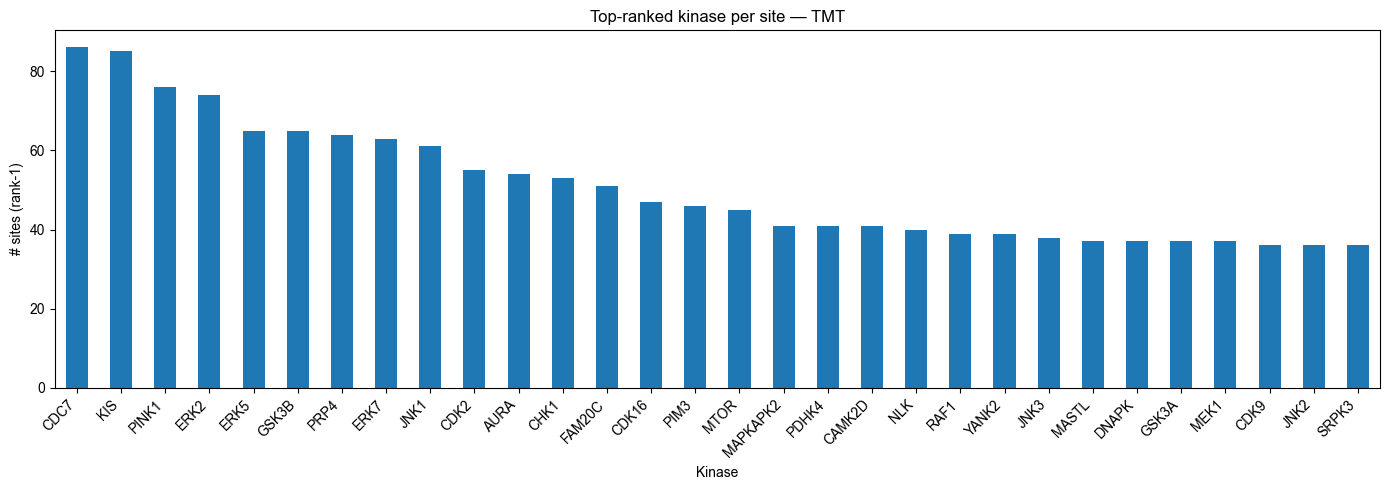

In [10]:
# Top-ranked kinase distribution — expect CK2 / CDK / MAPK / GSK3 families to dominate S/T,
# with tyrosine kinases (SRC / EGFR / ABL / SYK) appearing for Y sites.
top_counts = df_annotated["predicted_kinase_1"].value_counts().head(30)

fig, ax = plt.subplots(figsize=(14, 5),)
top_counts.plot(kind="bar", ax=ax,)
ax.set_xlabel("Kinase")
ax.set_ylabel("# sites (rank-1)")
ax.set_title(f"Top-ranked kinase per site — {DATASET_TYPE}")
plt.xticks(rotation=45, ha="right",)
plt.tight_layout()
plt.show()

## Save

Writes the annotated dataset with a `_kinasepred` suffix (never overwrites the source).
Uncomment to run.

In [28]:
df_annotated.to_csv(OUTPUT_PATH, sep="\t", index=False,)
# print(f"Saved: {OUTPUT_PATH}")

## Cluster composition — kinases and proteins per cluster

Cross-tabulate any clustering column against the per-site annotations to ask:
- **which clusters contain sites phosphorylated by kinases X / Y / Z** (using the
  `predicted_kinase_*` columns), and
- **in which clusters given proteins appear**.

Set `CLUSTER_COL` to the clustering method you want to inspect. The dataset carries several
(one per method), e.g. `KMeans_adaptive_cluster_WT_EGF_log2_FC`,
`KMeans_11_cluster_WT_EGF_log2_zscore`, ...

In [25]:
# Which clustering column to inspect, and what to look up.
CLUSTER_COL   = "KMeans_adaptive_cluster_WT_EGF_log2_FC"
QUERY_KINASES = ["ERK2", "AKT1", "AKT2", "AKT3"]
QUERY_PROTEINS = ["EGFR", "BRAF", "GAB1", "SOS1", "SHOC2", "KSR1"]   # protein_name values (or set protein_col="protein_Id")
print("cluster columns available:")
print([c for c in df_annotated.columns if "cluster" in c.lower()])

cluster columns available:
['KMeans_adaptive_cluster_WT_EGF_log2_FC', 'KMeans_adaptive_cluster_WT_EGF_log2_scaled', 'KMeans_adaptive_cluster_WT_EGF_log2_zscore', 'KMeans_11_cluster_WT_EGF_log2_FC', 'KMeans_11_cluster_WT_EGF_log2_scaled', 'KMeans_11_cluster_WT_EGF_log2_zscore']


### Which clusters have sites phosphorylated by these kinases?

A site counts for a kinase if that kinase is among its top-5 predictions. Use `ranks=[1]`
for the top prediction only, or `min_percentile=` to require a confidence floor.

                                        ERK2  AKT1  AKT2  AKT3
KMeans_adaptive_cluster_WT_EGF_log2_FC                        
0                                        150     7    12    13
1                                         14     1     1     0
2                                         50     7     7     7
3                                         42     1     0     0
4                                          0     0     0     0
5                                          0     0     0     0
6                                          3     0     0     0
7                                          0     0     0     0
8                                          1     1     0     2
9                                          0     0     0     1
10                                         1     1     1     1


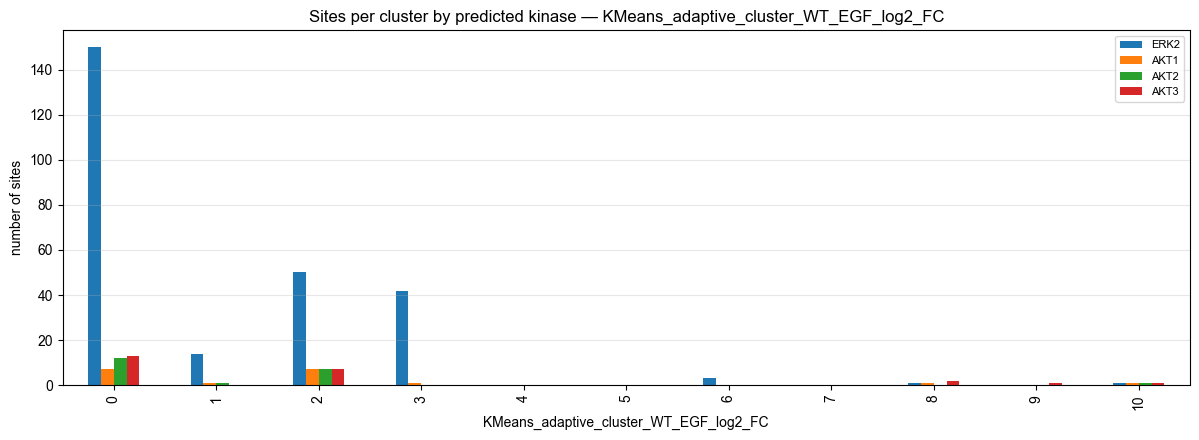

In [26]:
kin_table = kinase_cluster_table(df_annotated,
                                 cluster_col=CLUSTER_COL,
                                 kinases=QUERY_KINASES,
                                 top_n=TOP_N,)
print(kin_table)

fig, ax = plot_cluster_composition(kin_table,
                                   kind="bar",
                                   title=f"Sites per cluster by predicted kinase — {CLUSTER_COL}",)
plt.show()

### In which clusters do these proteins appear?

                                        EGFR  BRAF  GAB1  SOS1  SHOC2  KSR1
KMeans_adaptive_cluster_WT_EGF_log2_FC                                     
0                                          3     2     1     3      2     0
1                                          0     0     0     2      0     0
2                                          2     2     2     1      0     0
3                                          0     1     1     1      0     1
4                                          3     0     4     0      0     0
5                                          0     0     0     0      0     0
6                                          0     0     0     0      0     0
7                                          0     0     0     0      0     0
8                                          0     0     0     0      0     0
9                                          1     0     1     2      0     0
10                                         0     0     0     0      0     0


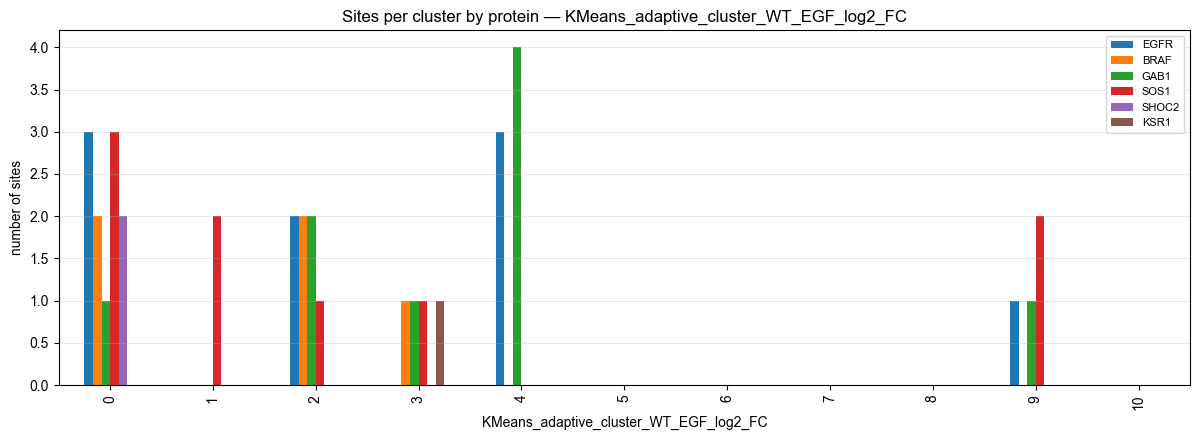

In [27]:
prot_table = protein_cluster_table(df_annotated,
                                   cluster_col=CLUSTER_COL,
                                   proteins=QUERY_PROTEINS,
                                   protein_col="protein_name",)
print(prot_table)

fig, ax = plot_cluster_composition(prot_table,
                                   kind="bar",
                                   title=f"Sites per cluster by protein — {CLUSTER_COL}",)
plt.show()